# 02 · Modeling combined fuel economy and CO₂ emissions

**Goal:** predict the certified combined fuel economy (`Comb FE (Guide)`, mpg) and CO₂ emissions (g/mi) of a
combustion vehicle from its technical specification (engine, transmission, drivetrain, class, fuel), without using
any quantity derived from the test itself.

## Evaluation protocol

| Element | Decision | Rationale |
|---|---|---|
| Hold-out | 30 % of **model families** (`GroupShuffleSplit`) | 2WD/AWD variants of a model are never split between training and test |
| Random CV | `KFold(5)` | Comparable with common practice |
| Grouped CV | `GroupKFold(5)` by family | **Selection metric**: performance on unseen vehicle models |
| Preprocessing | Inside a `Pipeline` | Scaling and one-hot encoding are fitted on training data only (no leakage) |
| Baseline | `DummyRegressor` (mean) | Every model must clearly beat predicting the mean |
| Metrics | MAE and RMSE in mpg, R² | Business-interpretable units |

In [1]:
try:
    import vehicle_emissions  # installed with `pip install -e .`
except ModuleNotFoundError:  # running without installing the package
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
RANDOM_STATE = 42

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures

from vehicle_emissions.data import add_binary_features, load_fe_guide
from vehicle_emissions.evaluation import evaluate_regressor, plot_pred_vs_real, plot_residuals, results_table
from vehicle_emissions.validation import validate_fe_guide

df = add_binary_features(load_fe_guide())
validate_fe_guide(df)  # data contract: stops execution if anything is off
for c in ["Comb FE (Guide)", "Comb CO2"]:
    df[c] = df[c].astype(float)
print(f"{len(df)} vehicles · {df['Model Family'].nunique()} model families")

964 vehicles · 596 model families


## 1. Features and split

| Group | Features |
|---|---|
| Numeric | `Eng Displ`, `# Cyl`, `# Gears`, `Hybrid` |
| Compact binary encoding | `AWD/4WD`, `Large` |
| Categorical (one-hot) | `Fuel Usage`, `Drive Desc`, `Carline Class Desc`, `Air Aspiration Method Desc`, `Cyl Deact?` |

In [3]:
TARGET = "Comb FE (Guide)"
NUM = ["Eng Displ", "# Cyl", "# Gears", "Hybrid"]
BIN = ["AWD/4WD", "Large"]
CAT = ["Fuel Usage", "Drive Desc", "Carline Class Desc", "Air Aspiration Method Desc", "Cyl Deact?"]
GROUPS = df["Model Family"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_STATE)
idx_tr, idx_te = next(splitter.split(df, groups=GROUPS))
train, test = df.iloc[idx_tr], df.iloc[idx_te]
assert not set(train["Model Family"]) & set(test["Model Family"]), "model families leak between train and test"
print(f"Training: {len(train)} vehicles · Test: {len(test)} vehicles · shared families: 0")

results = []
def run(name, model, cols, target=TARGET, data=df):
    tr, te = data.loc[data.index.isin(train.index)], data.loc[data.index.isin(test.index)]
    r = evaluate_regressor(name, model, tr[cols], te[cols], tr[target], te[target],
                           data[cols], data[target], groups=data["Model Family"])
    r.update(_y_test=te[target].to_numpy(), _model=model, _X_test=te[cols])
    results.append(r)
    return r

Training: 668 vehicles · Test: 296 vehicles · shared families: 0


## 2. Baseline

In [4]:
run("M0 Baseline · mean", DummyRegressor(), NUM)
results_table(results)

,MAE,RMSE,R2,R2 CV,± std,R2 grouped CV,MAE grouped CV
Experiment,,,,,,,
M0 Baseline · mean,5.243,7.202,-0.001,-0.011,0.011,-0.001,4.95


## 3. Linear models with binary encoding

It is explicitly verified that scaling does not change a linear regression (the model is invariant to affine
transformations of the features), so scaling is kept only for numerical stability.

In [5]:
cols_bin = NUM + BIN
r1 = run("M1 Linear · binary", LinearRegression(), cols_bin)
check = make_pipeline(MinMaxScaler(), LinearRegression()).fit(train[cols_bin], train[TARGET])
assert np.allclose(check.predict(test[cols_bin]), r1["_y_pred"]), "scaling should not change a linear regression"
print("Scaling invariance verified")

r2 = run("M2 Polynomial d2 · binary",
         make_pipeline(MinMaxScaler(), PolynomialFeatures(degree=2), LinearRegression()), cols_bin)
results_table(results)

Scaling invariance verified


,MAE,RMSE,R2,R2 CV,± std,R2 grouped CV,MAE grouped CV
Experiment,,,,,,,
M0 Baseline · mean,5.243,7.202,-0.001,-0.011,0.011,-0.001,4.950
M1 Linear · binary,2.817,3.800,0.721,0.726,0.022,0.722,2.604
M2 Polynomial d2 · binary,2.418,3.270,0.794,0.794,0.011,0.781,2.289


## 4. Linear regression with one-hot encoding

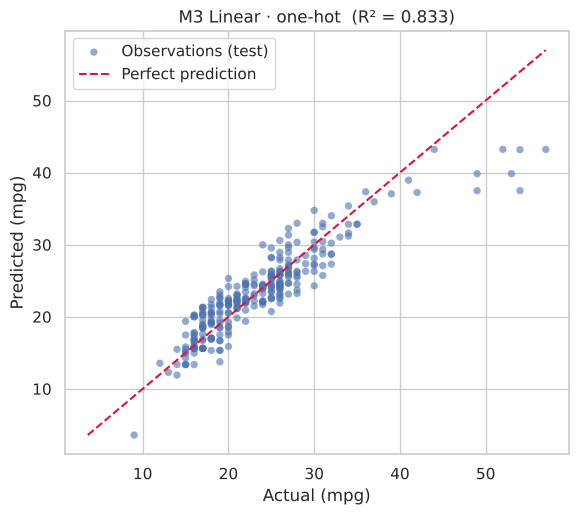

In [6]:
def preprocessor(scale=True):
    return ColumnTransformer([("num", MinMaxScaler() if scale else "passthrough", NUM),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])

r3 = run("M3 Linear · one-hot", Pipeline([("pre", preprocessor()), ("model", LinearRegression())]), NUM + CAT)
plot_pred_vs_real(r3["_y_test"], r3["_y_pred"], "M3 Linear · one-hot", "(mpg)", save_as="02_M3_linear_onehot.png")
plt.show()

## 5. Gradient Boosting with hyperparameter tuning

The search runs **on the training split only** with `GroupKFold`, so the test split plays no part in any decision.

Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
Grouped CV MAE (training): 1.50 mpg


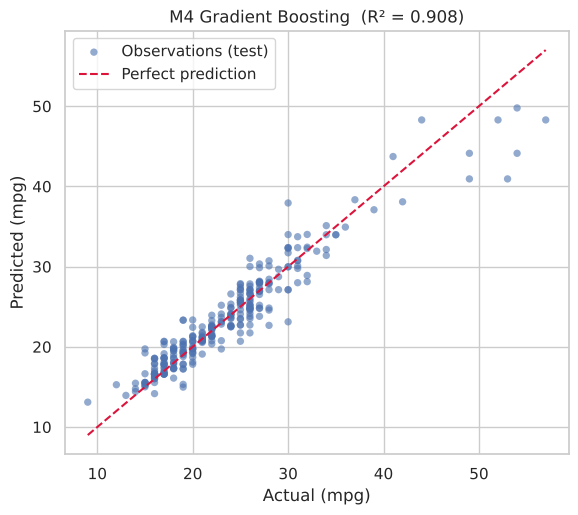

In [7]:
gb_pipe = Pipeline([("pre", preprocessor(scale=False)), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])
search = GridSearchCV(
    gb_pipe,
    {"model__n_estimators": [200, 400], "model__max_depth": [2, 3, 4], "model__learning_rate": [0.05, 0.1],
     "model__subsample": [0.8, 1.0]},
    cv=GroupKFold(n_splits=5), scoring="neg_mean_absolute_error", n_jobs=-1,
)
search.fit(train[NUM + CAT], train[TARGET], groups=train["Model Family"])
print("Best hyperparameters:", {k.split("__")[1]: v for k, v in search.best_params_.items()})
print(f"Grouped CV MAE (training): {-search.best_score_:.2f} mpg")

r4 = run("M4 Gradient Boosting · one-hot", search.best_estimator_, NUM + CAT)
plot_pred_vs_real(r4["_y_test"], r4["_y_pred"], "M4 Gradient Boosting", "(mpg)", save_as="02_M4_gradient_boosting.png")
plt.show()

## 6. Model comparison

In [8]:
table = results_table(results)
table

,MAE,RMSE,R2,R2 CV,± std,R2 grouped CV,MAE grouped CV
Experiment,,,,,,,
M0 Baseline · mean,5.243,7.202,-0.001,-0.011,0.011,-0.001,4.950
M1 Linear · binary,2.817,3.800,0.721,0.726,0.022,0.722,2.604
M2 Polynomial d2 · binary,2.418,3.270,0.794,0.794,0.011,0.781,2.289
M3 Linear · one-hot,2.088,2.943,0.833,0.843,0.009,0.837,1.956
M4 Gradient Boosting · one-hot,1.485,2.181,0.908,0.921,0.007,0.906,1.412


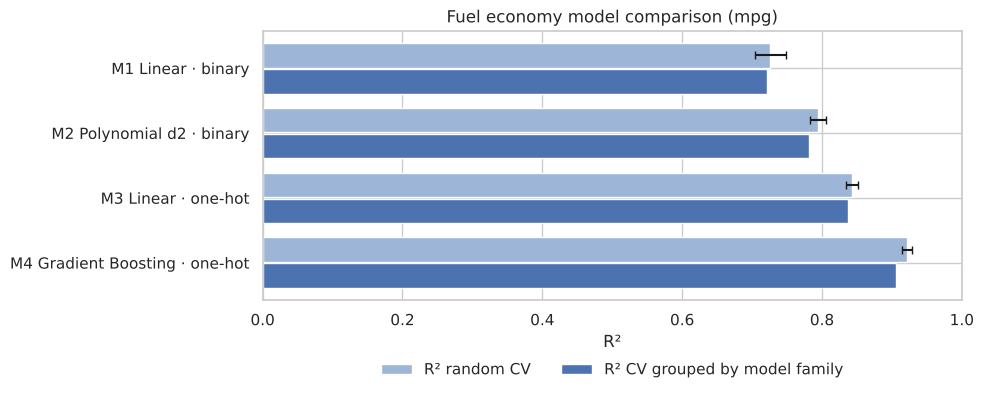

In [9]:
t = table.drop(index="M0 Baseline · mean")
fig, ax = plt.subplots(figsize=(10, 4.2))
y = np.arange(len(t))
ax.barh(y - 0.2, t["R2 CV"], height=0.38, color="#9DB5D6", label="R² random CV")
ax.barh(y + 0.2, t["R2 grouped CV"], height=0.38, color="#4C72B0", label="R² CV grouped by model family")
ax.errorbar(t["R2 CV"], y - 0.2, xerr=t["± std"], fmt="none", color="k", capsize=3)
ax.set_yticks(y, t.index); ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("R²")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
ax.set_title("Fuel economy model comparison (mpg)")
fig.tight_layout(); fig.savefig("../reports/figures/02_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Robustness studies

### 7.1 Feature ablation

How much does each block contribute? The best model is retrained with groups of features removed.

In [10]:
best_params = {k.split("__")[1]: v for k, v in search.best_params_.items()}
def gb_with(num, cat):
    pre = ColumnTransformer([("num", "passthrough", num)] + ([("cat", OneHotEncoder(handle_unknown="ignore"), cat)] if cat else []))
    return Pipeline([("pre", pre), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, **best_params))])

ablation = {}
for name, num, cat in [("Full model", NUM, CAT),
                       ("Without `Hybrid`", [c for c in NUM if c != "Hybrid"], CAT),
                       ("Without vehicle class", NUM, [c for c in CAT if c != "Carline Class Desc"]),
                       ("Engine only (displacement, cylinders, gears, hybrid)", NUM, []),
                       ("Displacement only", ["Eng Displ"], [])]:
    s = cross_validate(gb_with(num, cat), df[num + cat], df[TARGET], groups=GROUPS, cv=GroupKFold(5),
                       scoring=("r2", "neg_mean_absolute_error"))
    ablation[name] = {"R² grouped CV": s["test_r2"].mean(), "MAE grouped CV": -s["test_neg_mean_absolute_error"].mean()}
pd.DataFrame(ablation).T.round(3)

,R² grouped CV,MAE grouped CV
Full model,0.906,1.412
Without `Hybrid`,0.769,1.835
Without vehicle class,0.885,1.558
"Engine only (displacement, cylinders, gears, hybrid)",0.807,2.067
Displacement only,0.608,2.656


### 7.2 Sensitivity to extreme values

The fuel economy extremes are real hybrids. We check whether trimming them (P98 of the training split) improves the
linear model or merely flatters the metric by removing the hard cases.

In [11]:
q98 = train[TARGET].quantile(0.98)
trimmed = df[df[TARGET] < q98]
tr_t, te_t = trimmed.index.isin(train.index), trimmed.index.isin(test.index)
r_trim = evaluate_regressor("M3 without extremes (P98)", Pipeline([("pre", preprocessor()), ("model", LinearRegression())]),
                            trimmed.loc[tr_t, NUM + CAT], trimmed.loc[te_t, NUM + CAT],
                            trimmed.loc[tr_t, TARGET], trimmed.loc[te_t, TARGET],
                            trimmed[NUM + CAT], trimmed[TARGET], groups=trimmed["Model Family"])
print(f"P98 threshold = {q98:.0f} mpg · vehicles removed: {len(df) - len(trimmed)} "
      f"({(df[TARGET] >= q98).groupby(df['Hybrid']).sum().get(1, 0)} hybrids)")
results_table([r3, r_trim])

P98 threshold = 40 mpg · vehicles removed: 24 (23 hybrids)


,MAE,RMSE,R2,R2 CV,± std,R2 grouped CV,MAE grouped CV
Experiment,,,,,,,
M3 Linear · one-hot,2.088,2.943,0.833,0.843,0.009,0.837,1.956
M3 without extremes (P98),1.797,2.223,0.824,0.818,0.038,0.816,1.798


### 7.3 Choice of target: mpg vs CO₂

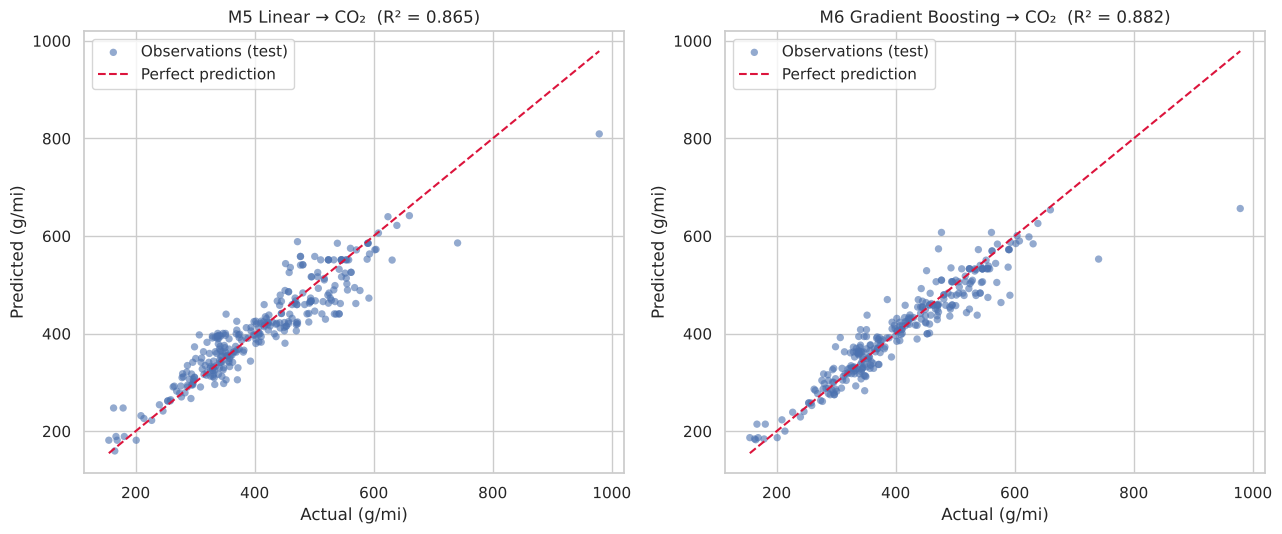

,MAE,RMSE,R2,R2 CV,± std,R2 grouped CV,MAE grouped CV
Experiment,,,,,,,
M3 Linear · one-hot,2.088,2.943,0.833,0.843,0.009,0.837,1.956
M5 Linear · one-hot → CO₂ (g/mi),29.475,40.221,0.865,0.847,0.023,0.848,29.674
M4 Gradient Boosting · one-hot,1.485,2.181,0.908,0.921,0.007,0.906,1.412
M6 Gradient Boosting · one-hot → CO₂ (g/mi),23.592,37.514,0.882,0.892,0.026,0.887,23.232


In [12]:
r5 = run("M5 Linear · one-hot → CO₂ (g/mi)", Pipeline([("pre", preprocessor()), ("model", LinearRegression())]),
         NUM + CAT, target="Comb CO2")
r6 = run("M6 Gradient Boosting · one-hot → CO₂ (g/mi)",
         Pipeline([("pre", preprocessor(scale=False)), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, **best_params))]),
         NUM + CAT, target="Comb CO2")
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
plot_pred_vs_real(r5["_y_test"], r5["_y_pred"], "M5 Linear → CO₂", "(g/mi)", ax=axs[0])
plot_pred_vs_real(r6["_y_test"], r6["_y_pred"], "M6 Gradient Boosting → CO₂", "(g/mi)", ax=axs[1])
fig.tight_layout(); fig.savefig("../reports/figures/02_M5-M6_co2.png", dpi=150, bbox_inches="tight")
plt.show()
results_table(results).loc[["M3 Linear · one-hot", "M5 Linear · one-hot → CO₂ (g/mi)",
                            "M4 Gradient Boosting · one-hot", "M6 Gradient Boosting · one-hot → CO₂ (g/mi)"]]

## 8. Diagnostics of the selected model (M4)

### 8.1 Residuals

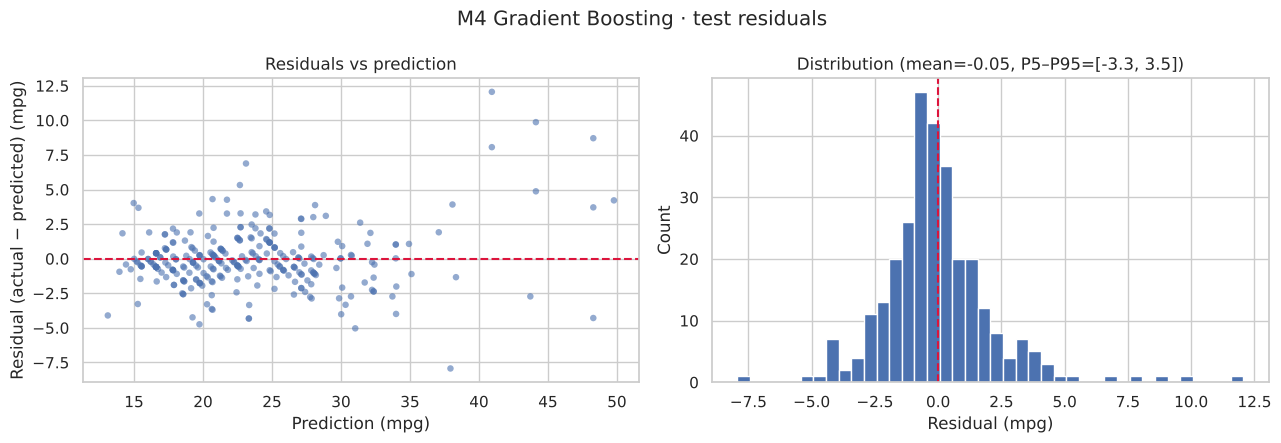

In [13]:
plot_residuals(r4["_y_test"], r4["_y_pred"], "(mpg)", "M4 Gradient Boosting · test residuals",
               save_as="02_M4_residuals.png")
plt.show()

In [14]:
seg = test.assign(abs_err=np.abs(r4["_y_test"] - r4["_y_pred"]))
seg_table = pd.concat({
    "Type": seg.groupby(seg["Hybrid"].map({0: "Conventional", 1: "Hybrid"}))["abs_err"].agg(["count", "mean"]),
    "Fuel": seg.groupby(seg["Gasoline"].map({0: "Diesel", 1: "Gasoline"}))["abs_err"].agg(["count", "mean"]),
    "Size": seg.groupby(seg["Large"].map({0: "Compact", 1: "Large"}))["abs_err"].agg(["count", "mean"]),
}).rename(columns={"count": "n (test)", "mean": "MAE (mpg)"}).round(2)
seg_table

n (test)  MAE (mpg)
Type Conventional       280       1.29
     Hybrid              16       4.90
Fuel Diesel               6       0.84
     Gasoline           290       1.50
Size Compact            163       1.51
     Large              133       1.46

### 8.2 Permutation importance

Computed on the test split (unseen families) over the original features, not over the one-hot columns.

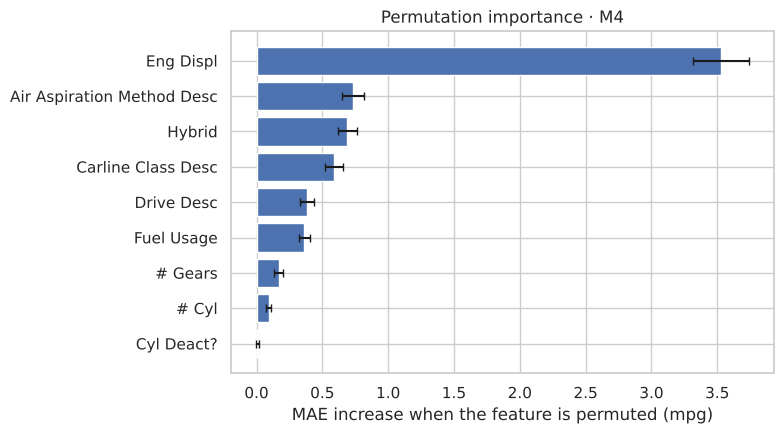

,MAE increase (mpg),± std
Eng Displ,3.528,0.216
Air Aspiration Method Desc,0.735,0.084
Hybrid,0.690,0.071
Carline Class Desc,0.585,0.069
Drive Desc,0.384,0.052
Fuel Usage,0.364,0.042
# Gears,0.167,0.032
# Cyl,0.091,0.018
Cyl Deact?,0.006,0.013


In [15]:
pi = permutation_importance(r4["_model"], r4["_X_test"], r4["_y_test"], n_repeats=20,
                            random_state=RANDOM_STATE, scoring="neg_mean_absolute_error")
imp = pd.DataFrame({"MAE increase (mpg)": pi.importances_mean, "± std": pi.importances_std},
                   index=r4["_X_test"].columns).sort_values("MAE increase (mpg)")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp.index, imp["MAE increase (mpg)"], xerr=imp["± std"], color="#4C72B0", capsize=3)
ax.set(xlabel="MAE increase when the feature is permuted (mpg)", title="Permutation importance · M4")
fig.tight_layout(); fig.savefig("../reports/figures/02_M4_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()
imp.sort_values("MAE increase (mpg)", ascending=False).round(3)

## 9. Conclusions

* **Selected model: Gradient Boosting with one-hot encoding (M4).** On unseen model families it reaches
  **R² ≈ 0.91 and MAE ≈ 1.4 mpg**, versus 4.9 mpg for the baseline and 2.0 mpg for the best linear model.
* **Encoding matters more than the linear algorithm:** moving from binary flags (M1) to one-hot (M3) reduces the
  grouped MAE from 2.6 to 2.0 mpg. The polynomial term (M2) recovers part of the non-linearity, but Gradient Boosting
  captures it better.
* **The validation is honest:** the gap between random CV and family-grouped CV is small (≈ 0.01-0.02 R²), so variants
  of the same model were not inflating the results on this dataset.
* **What drives fuel economy:** displacement dominates by far (permuting it multiplies the error), followed by air
  aspiration, hybridization and vehicle class. Removing `Hybrid` drops R² from 0.91 to 0.77, and displacement alone
  explains ≈ 0.61.
* **Trimming extremes is not an improvement:** it lowers the MAE only because it removes 23 hybrids, the hardest cases.
  They are kept.
* **The linear model works better for CO₂ than for mpg** (R² 0.85 vs 0.84), consistent with CO₂ being proportional to
  fuel burned per distance.
* **Main limitation:** the error on hybrids (MAE ≈ 4.9 mpg) is almost four times that of conventional vehicles
  (≈ 1.3 mpg). The guide does not report battery capacity or electric power; adding them is the highest-return improvement.